# Bevölkerung nach Stadtquartier


### Kurzbeschreibung
Wirtschaftliche Wohnbevölkerung der Stadt Zürich nach Statistischem Stadtquartier und Jahr.

Datum: 04.02.205


Dataset auf PROD-Datakatalog: Link https://data.stadt-zuerich.ch/dataset/bev_bestand_jahr_quartier_od3240

Dataset auf INTEG-Datakatalog: Link https://data.integ.stadt-zuerich.ch/dataset/int_dwh_bev_bestand_jahr_quartier_od3240


### Importiere die notwendigen Packages

In [1]:
#%pip install geopandas altair fiona requests folium mplleaflet contextily seaborn datetime plotly leafmap

In [2]:
import altair as alt
import datetime
import folium 
import geopandas as gpd
import io
from IPython.display import Markdown as md
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
#import pivottablejs
#from pivottablejs import pivot_ui
import plotly.express as px
import requests
import seaborn as sns

Importiere die eigenen Funktionen, die unter ../0_scripts abegelegt sind:

In [3]:
import sys
sys.path.append('../0_scripts')

import my_py_dataviz_functions as mypy_dv
import my_py_dataloading_functions as mypy_dl

In [4]:
SSL_VERIFY = False
# evtl. SSL_VERIFY auf False setzen wenn die Verbindung zu https://www.gemeinderat-zuerich.ch nicht klappt (z.B. wegen Proxy)
# Um die SSL Verifikation auszustellen, bitte die nächste Zeile einkommentieren ("#" entfernen)
# SSL_VERIFY = False

In [5]:
if not SSL_VERIFY:
    import urllib3
    urllib3.disable_warnings()

### Settings
Definiere Settings. 
Hier das Zahlenformat von Float-Werten (z.B. *'{:,.2f}'.format* mit Komma als Tausenderzeichen)

In [6]:
#pd.options.display.float_format = lambda x : '{:,.1f}'.format(x) if (np.isnan(x) | np.isinf(x)) else '{:,.0f}'.format(x) if int(x) == x else '{:,.1f}'.format(x)
pd.options.display.float_format = '{:.0f}'.format
pd.set_option('display.width', 100)
pd.set_option('display.max_columns', 15)

#### Zeitvariabeln


In [7]:
#Zeitvariabeln als Strings:
now = datetime.date.today()
year_today = now.strftime("%Y")
date_today = "_"+now.strftime("%Y-%m-%d")

#Zeitvariabeln als Integers:
int_times = now.timetuple()
aktuellesJahr = int_times[0]
aktuellerMonat = int_times[1]
selectedMonat = int_times[1]-2
#print(aktuellesJahr, aktuellerMonat,'datenstand: ', selectedMonat, int_times)

### Daten importieren und Metadaten checken

- status: int / prod
- data_source: web / ld / dropzone
- datums_attr: beschreibt das oder die Datumsfelder, die als Datum geparsed werden sollen. Falls es keines gibt: None

In [8]:
package_name = "bev_bestand_jahr_quartier_od3240"

In [9]:
data2betested = mypy_dl.load_data(
    status = 'int'
    , data_source = 'web'
    , package_name = package_name
    , dataset_name = "BEV324OD3240"    
    , datums_attr = ['StichtagDatJahr']
    )

fp lautet:https://data.integ.stadt-zuerich.ch/dataset/int_dwh_bev_bestand_jahr_quartier_od3240/download/BEV324OD3240.csv


 **Überprüfe die Metadaten:**

 **Dataset auf INTEG-Datakatalog:** Link https://data.integ.stadt-zuerich.ch/dataset/int_dwh_bev_bestand_jahr_quartier_od3240 

 **Dataset auf PROD-Datakatalog:** Link https://data.stadt-zuerich.ch/dataset/bev_bestand_jahr_quartier_od3240 

data_source: web


In [10]:
data2betested.head(2).T

,0,1
StichtagDatJahr,2024-01-01 00:00:00,2023-01-01 00:00:00
QuarSort,11,11
QuarLang,Rathaus,Rathaus
AnzBestWir,3260,3343


Berechne weitere Attribute falls notwendig

In [11]:
data2betested = (
    data2betested
    .copy()
    .assign(
        #Aktualisierungs_Datum_str= lambda x: x.Aktualisierungs_Datum.astype(str),
        StichtagDatJahr_str = lambda x: x.StichtagDatJahr.astype(str),
        Jahr = lambda x: x.StichtagDatJahr,
        Jahr_end = lambda x: x.StichtagDatJahr+pd.offsets.YearEnd(0),
        Jahr_nbr = lambda x: x.Jahr.dt.year,
    )
    .sort_values('StichtagDatJahr', ascending=False)
    )
data2betested.dtypes

StichtagDatJahr        datetime64[ns]
QuarSort                        int64
QuarLang                       object
AnzBestWir                    float64
StichtagDatJahr_str            object
Jahr                   datetime64[ns]
Jahr_end               datetime64[ns]
Jahr_nbr                        int32
dtype: object

In [12]:
data2betested.head(2).T

,0,1564
StichtagDatJahr,2024-01-01 00:00:00,2024-01-01 00:00:00
QuarSort,11,72
QuarLang,Rathaus,Hottingen
AnzBestWir,3260,11531
StichtagDatJahr_str,2024-01-01,2024-01-01
Jahr,2024-01-01 00:00:00,2024-01-01 00:00:00
Jahr_end,2024-12-31 00:00:00,2024-12-31 00:00:00
Jahr_nbr,2024,2024


Minimales und maximales Jahr im Datensatz

In [13]:
data_max_jahr = str(max(data2betested.Jahr).year)
data_min_jahr = str(min(data2betested.Jahr).year)

print(f"Die Daten haben ein Minimumjahr von {data_min_jahr} und ein Maximumjahr von {data_max_jahr}")

Die Daten haben ein Minimumjahr von 1941 und ein Maximumjahr von 2024


In [14]:
data_max_date = max(data2betested.Jahr_end).strftime('%Y-%m-%d')
data_min_date = min(data2betested.Jahr_end).strftime('%Y-%m-%d')


print(f"Die Daten haben ein Minimumjahr von {data_min_date} und ein Maximumjahr von {data_max_date}")

Die Daten haben ein Minimumjahr von 1941-12-31 und ein Maximumjahr von 2024-12-31


### Einfache Datentests

In [15]:
data2betested.info(memory_usage='deep', verbose=True)

<class 'pandas.core.frame.DataFrame'>
Index: 2960 entries, 0 to 2959
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   StichtagDatJahr      2960 non-null   datetime64[ns]
 1   QuarSort             2960 non-null   int64         
 2   QuarLang             2960 non-null   object        
 3   AnzBestWir           2789 non-null   float64       
 4   StichtagDatJahr_str  2960 non-null   object        
 5   Jahr                 2960 non-null   datetime64[ns]
 6   Jahr_end             2960 non-null   datetime64[ns]
 7   Jahr_nbr             2960 non-null   int32         
dtypes: datetime64[ns](3), float64(1), int32(1), int64(1), object(2)
memory usage: 543.0 KB


In [16]:
print(f'The dataset has {data2betested.shape[0]:,.0f} rows (observations) and {data2betested.shape[1]:,.0f} columns (variables).')
print(f'There seem to be {data2betested.duplicated().sum()} exact duplicates in the data.')

The dataset has 2,960 rows (observations) and 8 columns (variables).
There seem to be 0 exact duplicates in the data.


Beschreibe einzelne Attribute

In [17]:
data2betested.describe()

,StichtagDatJahr,QuarSort,AnzBestWir,Jahr,Jahr_end,Jahr_nbr
count,2960,2960,2789,2960,2960,2960
mean,1981-12-09 04:05:11.351351360,65,11788,1981-12-09 04:05:11.351351360,1982-12-08 10:05:11.351351360,1982
min,1941-01-01 00:00:00,11,634,1941-01-01 00:00:00,1941-12-31 00:00:00,1941
25%,1961-01-01 00:00:00,33,6077,1961-01-01 00:00:00,1961-12-31 00:00:00,1961
50%,1982-01-01 00:00:00,67,10461,1982-01-01 00:00:00,1982-12-31 00:00:00,1982
75%,2003-01-01 00:00:00,92,16971,2003-01-01 00:00:00,2003-12-31 00:00:00,2003
max,2024-01-01 00:00:00,123,36315,2024-01-01 00:00:00,2024-12-31 00:00:00,2024
std,NaN,36,7450,NaN,NaN,24


Welches sind die Quartiere ohne Werte bei BEW?

In [18]:
data2betested[np.isnan(data2betested.AnzBestWir)]

,StichtagDatJahr,QuarSort,QuarLang,AnzBestWir,StichtagDatJahr_str,Jahr,Jahr_end,Jahr_nbr
672,1992-01-01,32,Kreis 3 südlicher Teil (Alt-Wiedikon und Fries...,NaN,1992-01-01,1992-01-01,1992-12-31,1992
2656,1992-01-01,120,Schwamendingen (ganzer Kreis 12),NaN,1992-01-01,1992-01-01,1992-12-31,1992
673,1991-01-01,32,Kreis 3 südlicher Teil (Alt-Wiedikon und Fries...,NaN,1991-01-01,1991-01-01,1991-12-31,1991
2657,1991-01-01,120,Schwamendingen (ganzer Kreis 12),NaN,1991-01-01,1991-01-01,1991-12-31,1991
2658,1990-01-01,120,Schwamendingen (ganzer Kreis 12),NaN,1990-01-01,1990-01-01,1990-12-31,1990
...,...,...,...,...,...,...,...,...
2791,1941-01-01,121,Saatlen,NaN,1941-01-01,1941-01-01,1941-12-31,1941
671,1941-01-01,31,Alt-Wiedikon,NaN,1941-01-01,1941-01-01,1941-12-31,1941
2875,1941-01-01,122,Schwamendingen-Mitte,NaN,1941-01-01,1941-01-01,1941-12-31,1941
807,1941-01-01,33,Friesenberg,NaN,1941-01-01,1941-01-01,1941-12-31,1941


### Verwende das Datum als Index

While we did already parse the `datetime` column into the respective datetime type, it currently is just a regular column. 
**To enable quick and convenient queries and aggregations, we need to turn it into the index of the DataFrame**

In [19]:
data2betested = data2betested.set_index("StichtagDatJahr")
data2betested = data2betested.sort_index()

In [20]:
data2betested.index.year.unique()

Index([1941, 1942, 1943, 1944, 1945, 1946, 1947, 1948, 1949, 1950, 1951, 1952, 1953, 1954, 1955,
       1956, 1957, 1958, 1959, 1960, 1961, 1962, 1963, 1964, 1965, 1966, 1967, 1968, 1969, 1970,
       1971, 1972, 1973, 1974, 1975, 1976, 1977, 1978, 1979, 1980, 1981, 1982, 1983, 1984, 1985,
       1986, 1987, 1988, 1989, 1990, 1991, 1992, 1993, 1994, 1995, 1996, 1997, 1998, 1999, 2000,
       2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015,
       2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024],
      dtype='int32', name='StichtagDatJahr')

### Beschreibe einzelne Attribute

Beschreibe nicht numerische Attribute

In [21]:
# describe non-numerical features
try:
    with pd.option_context('display.float_format', '{:,.2f}'.format):
        display(data2betested.describe(exclude='number',datetime_is_numeric=True))
except:
    print("No categorical data in dataset.")

No categorical data in dataset.


Beschreibe numerische Attribute

In [22]:
# describe numerical features
try:
    with pd.option_context('display.float_format', '{:,.0f}'.format):
        display(data2betested.describe(include='number'))
except:
    print("No numercial data in dataset.")

,QuarSort,AnzBestWir,Jahr_nbr
count,"2,960","2,789","2,960"
mean,65,"11,788","1,982"
std,36,"7,450",24
min,11,634,"1,941"
25%,33,"6,077","1,961"
50%,67,"10,461","1,982"
75%,92,"16,971","2,003"
max,123,"36,315","2,024"


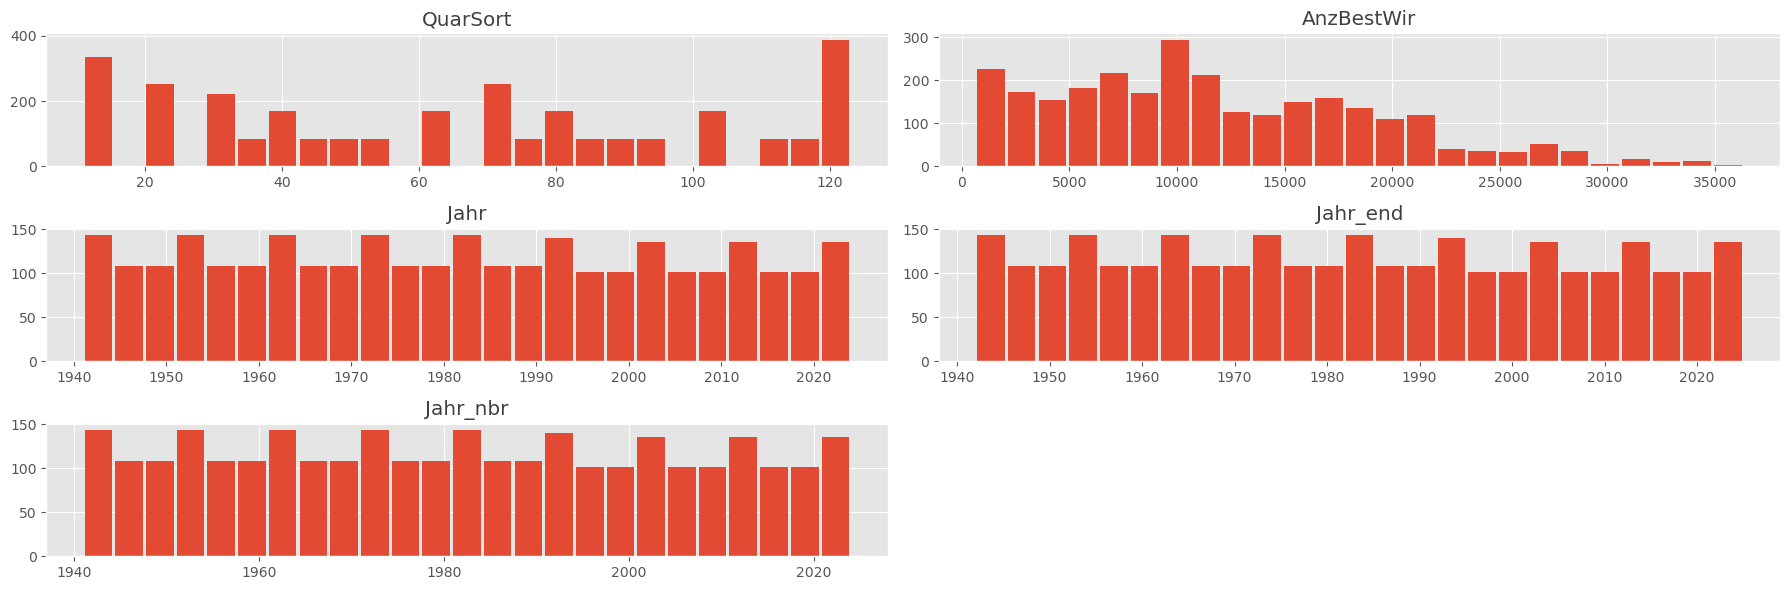

In [23]:
plt.style.use('ggplot')
params = {
    'text.color': (0.25, 0.25, 0.25),
    'figure.figsize': [18, 6],
   }
plt.rcParams.update(params)

try:
    data2betested.hist(bins=25, rwidth=0.9)
    plt.tight_layout()
    plt.show()
except:
    print("No numercial data to plot.") 

### Gibt es Duplikate?

In [24]:
# find duplicate rows
duplicate_rows = data2betested[data2betested.duplicated()]
duplicate_rows

,QuarSort,QuarLang,AnzBestWir,StichtagDatJahr_str,Jahr,Jahr_end,Jahr_nbr
StichtagDatJahr,,,,,,,


### Nullwerte und Missings?

In [25]:
data2betested.isnull().sum()

QuarSort                 0
QuarLang                 0
AnzBestWir             171
StichtagDatJahr_str      0
Jahr                     0
Jahr_end                 0
Jahr_nbr                 0
dtype: int64

In [26]:
# check missing values with missingno
# https://github.com/ResidentMario/missingno
#import missingno as msno
#msno.matrix(data2betested, labels=True, sort='descending');
#msno.heatmap(data2betested)

### Gruppierungen

In [27]:
agg_jahr = data2betested.loc[data_min_date:data_max_date]\
    .groupby(['Jahr', 'Jahr_nbr', 'Jahr_end']) \
    .agg(sum_AnzBestWir=('AnzBestWir', 'sum')) \
    .sort_values('Jahr', ascending=False) 
agg_jahr.reset_index().head(3)

,Jahr,Jahr_nbr,Jahr_end,sum_AnzBestWir
0,2024-01-01,2024,2024-12-31,448664
1,2023-01-01,2023,2023-12-31,447082
2,2022-01-01,2022,2022-12-31,443037


In [28]:
agg_raum = data2betested.loc[data_min_date:data_max_date]\
    .groupby(['QuarSort', 'QuarLang',]) \
    .agg(sum_AnzBestWir=('AnzBestWir', 'sum')) \
    .sort_values('QuarSort', ascending=False) 
agg_raum.reset_index().head(3)

,QuarSort,QuarLang,sum_AnzBestWir
0,123,Hirzenbach,648971
1,122,Schwamendingen-Mitte,596631
2,121,Saatlen,390780


In [29]:
agg_raum_zeit = data2betested.loc[data_min_date:data_max_date]\
    .groupby(['Jahr_nbr', 'Jahr_end', 'QuarSort', 'QuarLang',]) \
    .agg(sum_AnzBestWir=('AnzBestWir', 'sum')) \
    .sort_values('Jahr_nbr', ascending=True) 
agg_raum_zeit.reset_index().head(3)

,Jahr_nbr,Jahr_end,QuarSort,QuarLang,sum_AnzBestWir
0,1942,1942-12-31,11,Rathaus,8986
1,1942,1942-12-31,73,Hirslanden,10937
2,1942,1942-12-31,74,Witikon,1137


In [30]:
data2betested.reset_index().columns

Index(['StichtagDatJahr', 'QuarSort', 'QuarLang', 'AnzBestWir', 'StichtagDatJahr_str', 'Jahr',
       'Jahr_end', 'Jahr_nbr'],
      dtype='object')

### Visualisierungen nach Zeitausschnitten

#### Entwicklung der Wohnbevölkerung nach Quartier

In [31]:
#data2betested.loc[data_min_date:'1970']\
#     .query('QuarSort < 40')\
myAgg1 = data2betested.loc[data_min_date:data_max_date]\
    .groupby(['StichtagDatJahr', 'QuarSort', 'QuarLang']) \
    .agg(sum_WBev=('AnzBestWir', 'sum')) \
    .sort_values('StichtagDatJahr', ascending=True) 

myAgg1.reset_index().head(3)

,StichtagDatJahr,QuarSort,QuarLang,sum_WBev
0,1942-01-01,11,Rathaus,8986
1,1942-01-01,73,Hirslanden,10937
2,1942-01-01,74,Witikon,1137


In [32]:
grafik1 = mypy_dv.plot_altair_multiline_highlight(
    data = myAgg1.reset_index().sort_values('QuarSort', ascending=True)
    ,x = 'StichtagDatJahr:T'
    ,y = 'sum_WBev:Q'
    ,x_beschriftung = 'Jahr'
    , y_beschriftung = 'Anz. Personen'
    ,category = "QuarLang:N"
    ,category_beschriftung= 'Legende:'
    ,warning_status = "ignore" #always or ignore
    ,myTitle="Entwicklung der Wohnbevölkerung nach Stadtquartier, seit "+data_min_date
)
grafik1

alt.LayerChart(...)

##### Kombinierte Grafik in Altair

In [33]:
# Kombiniere die Grafiken horizontal
top_row = alt.hconcat(grafik1, grafik1)
#combined_chart = alt.vconcat(top_row,grafik3)
combined_chart = alt.vconcat(grafik1, grafik1, spacing=20)

# Optional: Füge einen Titel für die gesamte Grafik hinzu
final_chart = combined_chart.properties(
    title="Alle Teilgrafiken in einer zusammengesetzt:    ",  
    background="#FDFDFD",
    padding={"left": 20, "top": 20, "right": 20, "bottom": 20},
    autosize={"type": "fit", "contains": "padding"}
)
#Legenden nicht zusammenfügen
final_chart = final_chart.resolve_scale(
    color='independent',
    shape='independent',
    size='independent'
)

# Zeigen Sie die Grafik an
final_chart

alt.VConcatChart(...)

#### Faced Grids

In [34]:
myFG = data2betested.reset_index().query('QuarSort != 0')
myFG

,StichtagDatJahr,QuarSort,QuarLang,AnzBestWir,StichtagDatJahr_str,Jahr,Jahr_end,Jahr_nbr
0,1941-01-01,123,Hirzenbach,NaN,1941-01-01,1941-01-01,1941-12-31,1941
1,1941-01-01,61,Unterstrass,26907,1941-01-01,1941-01-01,1941-12-31,1941
2,1941-01-01,42,Langstrasse,19968,1941-01-01,1941-01-01,1941-12-31,1941
3,1941-01-01,41,Werd,7653,1941-01-01,1941-01-01,1941-12-31,1941
4,1941-01-01,44,Hard,15878,1941-01-01,1941-01-01,1941-12-31,1941
...,...,...,...,...,...,...,...,...
2955,2024-01-01,83,Weinegg,5635,2024-01-01,2024-01-01,2024-12-31,2024
2956,2024-01-01,82,Mühlebach,6456,2024-01-01,2024-01-01,2024-12-31,2024
2957,2024-01-01,81,Seefeld,5807,2024-01-01,2024-01-01,2024-12-31,2024
2958,2024-01-01,111,Affoltern,27337,2024-01-01,2024-01-01,2024-12-31,2024


In [35]:
data2betested.columns

Index(['QuarSort', 'QuarLang', 'AnzBestWir', 'StichtagDatJahr_str', 'Jahr', 'Jahr_end',
       'Jahr_nbr'],
      dtype='object')

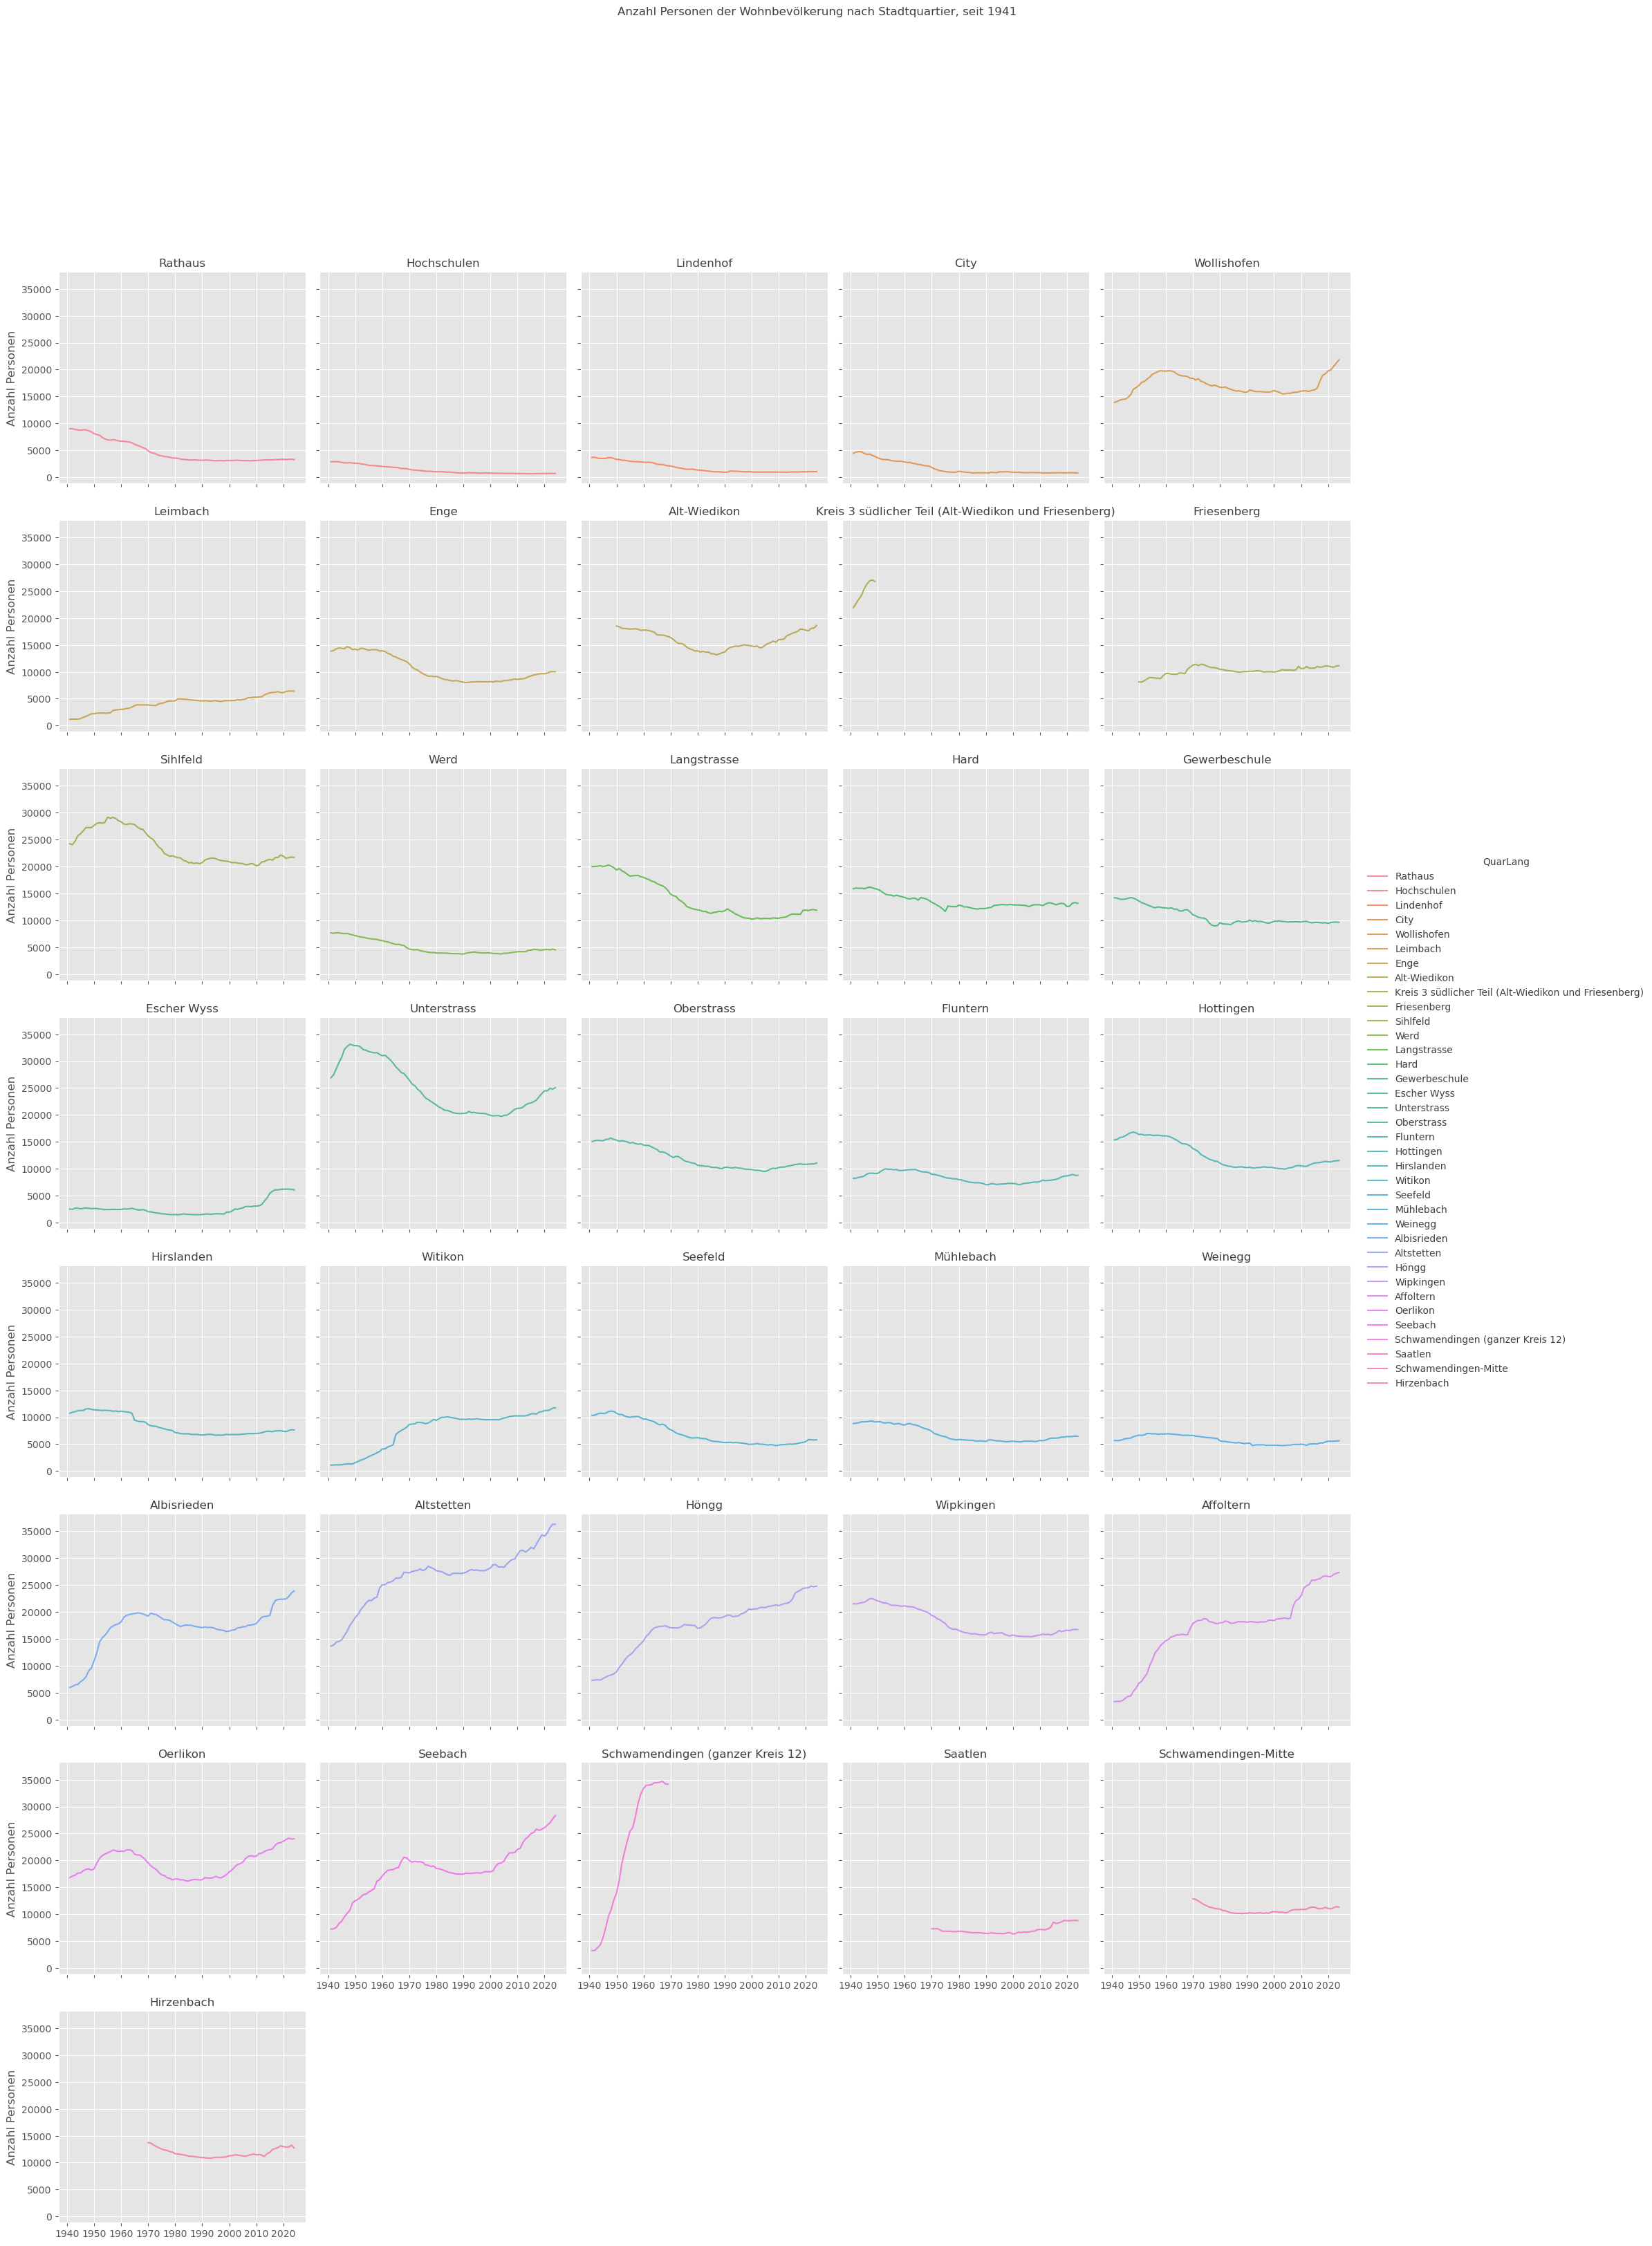

In [36]:
faced_grid1 = mypy_dv.plot_sns_facetgrid(
    data = myFG.reset_index().sort_values('QuarSort', ascending=True)
    ,col = "QuarLang"
    ,hue = "QuarLang"
    ,col_wrap = 5
    ,grafiktyp = sns.lineplot
    ,x = "StichtagDatJahr"
    ,y = "AnzBestWir"
    ,ylabel= "Anzahl Personen"
    ,warning_status ="ignore"
    ,height = 3
    ,myTitle="Anzahl Personen der Wohnbevölkerung nach Stadtquartier, seit "+str(int(data2betested.index.year.min()))
)
faced_grid1

#### Treemaps

**Funktion zum einfärben**

Muss ich noch als Funktion umsetzen 

In [37]:
  qual12br = ["#5D4BFE", "#4AA9FF", "#55FFFF", "#986AD5", "#FC4C99", "#FF919A", "#349894", "#44B14A", "#B7E14E", "#B97624", "#FF7231", "#FFD736"]
  qual12 = ["#3431DE", "#0A8DF6", "#23C3F1", "#7B4FB7", "#DB247D", "#FB737E", "#007C78", "#1F9E31", "#99C32E", "#9A5B01", "#FF720C", "#FBB900"]
  qual12da = ["#0017BF", "#0072D7", "#00A5D2", "#5E359A", "#BA0062", "#DA5563", "#00615D", "#00770F", "#7BA600", "#7B4100", "#DC5500", "#DA9C00"]
  div9val = ["#782600", "#CC4309", "#FF720C", "#FFBC88", "#E4E0DF", "#AECBFF", "#6B8EFF", "#3B51FF", "#2F2ABB",]
  div9ntr = ["#A30059", "#DB247D", "#FF579E", "#FFA8D0", "#E4E0DF", "#A8DBB1", "#55BC5D", "#1F9E31", "#10652A",]

In [38]:
# Extrahiere die Top-Fahrzeugmarken
zuzugsgebiet = data2betested['QuarLang'].unique().tolist()
# Verfügbare Farben
verfügbare_farben_zuericolors = qual12da+qual12br+qual12+div9ntr

# Erstelle das Farben-Dictionary
farben_dict_zc = {'(?)':'lightgrey'}
for index, x in enumerate(zuzugsgebiet):
    farben_dict_zc[x] = verfügbare_farben_zuericolors[index % len(verfügbare_farben_zuericolors)]

# Das resultierende Farben-Dictionary
print(farben_dict_zc)
#print(verfügbare_farben_zuericolors)

{'(?)': 'lightgrey', 'Hirzenbach': '#0017BF', 'Unterstrass': '#0072D7', 'Langstrasse': '#00A5D2', 'Werd': '#5E359A', 'Hard': '#BA0062', 'Affoltern': '#DA5563', 'Rathaus': '#00615D', 'City': '#00770F', 'Oberstrass': '#7BA600', 'Wipkingen': '#7B4100', 'Gewerbeschule': '#DC5500', 'Lindenhof': '#DA9C00', 'Fluntern': '#5D4BFE', 'Escher Wyss': '#4AA9FF', 'Sihlfeld': '#55FFFF', 'Saatlen': '#986AD5', 'Weinegg': '#FC4C99', 'Schwamendingen (ganzer Kreis 12)': '#FF919A', 'Mühlebach': '#349894', 'Witikon': '#44B14A', 'Höngg': '#B7E14E', 'Hottingen': '#B97624', 'Friesenberg': '#FF7231', 'Schwamendingen-Mitte': '#FFD736', 'Altstetten': '#3431DE', 'Hirslanden': '#0A8DF6', 'Hochschulen': '#23C3F1', 'Wollishofen': '#7B4FB7', 'Kreis 3 südlicher Teil (Alt-Wiedikon und Friesenberg)': '#DB247D', 'Leimbach': '#FB737E', 'Albisrieden': '#007C78', 'Seefeld': '#1F9E31', 'Alt-Wiedikon': '#99C32E', 'Oerlikon': '#9A5B01', 'Enge': '#FF720C', 'Seebach': '#FBB900'}


In [39]:
data2betested.columns

Index(['QuarSort', 'QuarLang', 'AnzBestWir', 'StichtagDatJahr_str', 'Jahr', 'Jahr_end',
       'Jahr_nbr'],
      dtype='object')

In [40]:
myTM = data2betested.loc[data_min_date:data_max_date].reset_index() \

myTM.reset_index().head(2)

,index,StichtagDatJahr,QuarSort,QuarLang,AnzBestWir,StichtagDatJahr_str,Jahr,Jahr_end,Jahr_nbr
0,0,1942-01-01,34,Sihlfeld,24062,1942-01-01,1942-01-01,1942-12-31,1942
1,1,1942-01-01,12,Hochschulen,2893,1942-01-01,1942-01-01,1942-12-31,1942


In [41]:
treeMap1 = mypy_dv.plot_px_treemap(
    data=myTM.reset_index()
    ,levels=['QuarLang','Jahr_nbr']
    ,values="AnzBestWir"
    ,color="AnzBestWir"
    #, color_continuous_scale='Blues'
    ,color_discrete_map={'(?)':'lightgrey', 'Wohnen':'lightblue'}   
    ,height=600
    ,width=1100               
    #,margin_val_bottom=25
    ,myHeaderTitle="Wohnbevölkerung nach Statistischem Quartier und Jahr, "+data_max_date
)
treeMap1

path: [<plotly.express._special_inputs.Constant object at 0x0000025D3718D6D0>, 'QuarLang', 'Jahr_nbr']
Typ von path: <class 'list'>


##### Wochenaufenthaltende nach Altersgruppe und Zuzugsgebiet

In [42]:
myTM2 = data2betested.loc[data_max_jahr]

myTM2.reset_index().head(2)

,StichtagDatJahr,QuarSort,QuarLang,AnzBestWir,StichtagDatJahr_str,Jahr,Jahr_end,Jahr_nbr
0,2024-01-01,61,Unterstrass,25078,2024-01-01,2024-01-01,2024-12-31,2024
1,2024-01-01,52,Escher Wyss,6077,2024-01-01,2024-01-01,2024-12-31,2024


In [43]:
treeMap2= mypy_dv.plot_px_treemap(
    data=myTM2.reset_index()
    ,levels=['QuarLang']
    ,values="AnzBestWir"
    ,color="QuarLang"
    #, color_continuous_scale='Blues'
    ,color_discrete_map=farben_dict_zc 
    ,height=600
    ,width=1100               
    #,margin_val_bottom=25
    ,myHeaderTitle="Wohnbevölkerung nach Statistischem Quartier am "+data_max_date
)
treeMap2

path: [<plotly.express._special_inputs.Constant object at 0x0000025D38D6DE50>, 'QuarLang']
Typ von path: <class 'list'>


## ---------------------- hier Plausi beendet

**Sharepoint als gecheckt markieren!**

Record auf Sharepoint: **[Link](https://kollaboration.intranet.stzh.ch/orga/ssz-produkte/_layouts/15/listform.aspx?PageType=4&ListId=%7BCB786184%2D948E%2D434B%2D98D5%2D3731AB652A28%7D&ID=44&ContentTypeID=0x0100988EAF029F1EFE4CA675F53C32A5D53D01006DBC563E6FBE9E4EB6FDC780799752E1)**

---------------------------------------------------------------------------